# LES Intercomparison Study for Neutral Boundary Layers: Sensitivity with respect to SGS Models

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

For case setup and physical parameters, see the [Description](NBL_A94_Description.ipynb) notebook.

SGS models compared: Static SM, LASDD-SM, LASDD-WL, LAD-SM, LAD-WL; grid: $256^3$ (DP).

## Setup

The next cells load Python packages, locate the simulation outputs, and define the grid and averaging window used throughout the notebook.


In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directories


In [2]:
from pathlib import Path

# Base directory (jaxalfa/)
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate jaxalfa repository root')

BaseDir = find_repo_root()

def read_config(run_dir):
    cfg = {}
    exec((run_dir / 'Config.py').read_text(), cfg)
    return cfg


optRes = 4  # 64x64x64: 1, 128x128x128: 2, 256x256x256: 3, 384x384x384: 4
optPrecision = 'SP'  # 'DP' or 'SP'

_res = {1: '64x64x64', 2: '128x128x128', 3: '256x256x256', 4: '384x384x384'}
_sgs = {1: 'LASDD_SM', 2: 'LASDD_WL', 3: 'LAD_SM', 4: 'LAD_WL'}

OutputDir1 = BaseDir / f'examples/NBL_A94/runs/{_res[optRes]}_{_sgs[1]}_{optPrecision}/output'
OutputDir2 = BaseDir / f'examples/NBL_A94/runs/{_res[optRes]}_{_sgs[2]}_{optPrecision}/output'
OutputDir3 = BaseDir / f'examples/NBL_A94/runs/{_res[optRes]}_{_sgs[3]}_{optPrecision}/output'
OutputDir4 = BaseDir / f'examples/NBL_A94/runs/{_res[optRes]}_{_sgs[4]}_{optPrecision}/output'


### Case configuration


In [3]:
cfg_1 = read_config(OutputDir1.parent)
nz_1 = int(cfg_1['nz'])
l_z = float(cfg_1['l_z'])
z_damping = float(cfg_1.get('z_damping', np.nan))
OutputInterval_sec = float(cfg_1.get('OutputInterval_sec', 60.0))

# Averaging window — keep the case-specific default used by this notebook
T_start = 73 * 3600   # s
T_end   = 83 * 3600   # s


### Derived grid and averaging indices


In [4]:
# Half levels — u, v, TH
z_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])

# Full levels — w, uw, vw, wTH, qz
z_w_1 = np.array([k * l_z / (nz_1 - 1) for k in range(nz_1)])

# File indices for the averaging window (same for all runs: same OutputInterval_sec)
T_start_index = int(T_start / OutputInterval_sec) - 1
T_end_index   = int(T_end   / OutputInterval_sec) - 1

print(f'Averaging window: file indices {T_start_index} – {T_end_index}')

Averaging window: file indices 4379 – 4979


### Statistics loader


In [5]:
def LoadStatsAverage(stat_files, T_start_index, T_end_index, nz_expected):
    if len(stat_files) == 0:
        print(f'No statistics files available; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return tuple(nan.copy() for _ in range(15))

    U   = []; V   = []; TH  = []
    u2  = []; v2  = []; w2  = []; TH2 = []
    uv  = []; uw  = []; vw  = []
    txy = []; txz = []; tyz = []
    wTH = []; qz  = []

    for f in stat_files:
        with np.load(f) as d:
            U.append(d['U']);   V.append(d['V']);   TH.append(d['TH'])
            u2.append(d['u2']); v2.append(d['v2']); w2.append(d['w2'])
            TH2.append(d['TH2'])
            uv.append(d['uv']); uw.append(d['uw']); vw.append(d['vw'])
            txy.append(d['txy']); txz.append(d['txz']); tyz.append(d['tyz'])
            wTH.append(d['wTH']); qz.append(d['qz'])

    U  = np.array(U);  V  = np.array(V);  TH  = np.array(TH)
    u2 = np.array(u2); v2 = np.array(v2); w2  = np.array(w2); TH2 = np.array(TH2)
    uv = np.array(uv); uw = np.array(uw); vw  = np.array(vw)
    txy = np.array(txy); txz = np.array(txz); tyz = np.array(tyz)
    wTH = np.array(wTH); qz = np.array(qz)

    sl = slice(T_start_index, min(T_end_index + 1, len(stat_files)))
    if sl.start >= len(stat_files):
        print(f'Averaging window starts after available files; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return tuple(nan.copy() for _ in range(15))

    return (
        np.mean(U[sl],   axis=0), np.mean(V[sl],   axis=0), np.mean(TH[sl],  axis=0),
        np.mean(u2[sl],  axis=0), np.mean(v2[sl],  axis=0), np.mean(w2[sl],  axis=0),
        np.mean(TH2[sl], axis=0),
        np.mean(uv[sl],  axis=0), np.mean(uw[sl],  axis=0), np.mean(vw[sl],  axis=0),
        np.mean(txy[sl], axis=0), np.mean(txz[sl], axis=0), np.mean(tyz[sl], axis=0),
        np.mean(wTH[sl], axis=0), np.mean(qz[sl],  axis=0)
    )


### Available statistics files


In [6]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles1 = get_stat_files(OutputDir1)
StatFiles2 = get_stat_files(OutputDir2)
StatFiles3 = get_stat_files(OutputDir3)
StatFiles4 = get_stat_files(OutputDir4)

### Temporally averaged profiles


In [7]:
(U_avg_1, V_avg_1, TH_avg_1,
 u2_avg_1, v2_avg_1, w2_avg_1, TH2_avg_1,
 uv_avg_1, uw_avg_1, vw_avg_1,
 txy_avg_1, txz_avg_1, tyz_avg_1,
 wTH_avg_1, qz_avg_1) = LoadStatsAverage(StatFiles1, T_start_index, T_end_index, nz_1)

(U_avg_2, V_avg_2, TH_avg_2,
 u2_avg_2, v2_avg_2, w2_avg_2, TH2_avg_2,
 uv_avg_2, uw_avg_2, vw_avg_2,
 txy_avg_2, txz_avg_2, tyz_avg_2,
 wTH_avg_2, qz_avg_2) = LoadStatsAverage(StatFiles2, T_start_index, T_end_index, nz_1)

(U_avg_3, V_avg_3, TH_avg_3,
 u2_avg_3, v2_avg_3, w2_avg_3, TH2_avg_3,
 uv_avg_3, uw_avg_3, vw_avg_3,
 txy_avg_3, txz_avg_3, tyz_avg_3,
 wTH_avg_3, qz_avg_3) = LoadStatsAverage(StatFiles3, T_start_index, T_end_index, nz_1)

(U_avg_4, V_avg_4, TH_avg_4,
 u2_avg_4, v2_avg_4, w2_avg_4, TH2_avg_4,
 uv_avg_4, uw_avg_4, vw_avg_4,
 txy_avg_4, txz_avg_4, tyz_avg_4,
 wTH_avg_4, qz_avg_4) = LoadStatsAverage(StatFiles4, T_start_index, T_end_index, nz_1)

M_avg_1   = np.sqrt(U_avg_1**2 + V_avg_1**2)
uw_tot_1  = uw_avg_1  + txz_avg_1
vw_tot_1  = vw_avg_1  + tyz_avg_1

M_avg_2   = np.sqrt(U_avg_2**2 + V_avg_2**2)
uw_tot_2  = uw_avg_2  + txz_avg_2
vw_tot_2  = vw_avg_2  + tyz_avg_2

M_avg_3   = np.sqrt(U_avg_3**2 + V_avg_3**2)
uw_tot_3  = uw_avg_3  + txz_avg_3
vw_tot_3  = vw_avg_3  + tyz_avg_3

M_avg_4   = np.sqrt(U_avg_4**2 + V_avg_4**2)
uw_tot_4  = uw_avg_4  + txz_avg_4
vw_tot_4  = vw_avg_4  + tyz_avg_4

print(f'Averaging over {T_end_index - T_start_index + 1} files '
      f'({T_start/3600:.1f}–{T_end/3600:.1f} h)')

Averaging over 601 files (73.0–83.0 h)


In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [9]:
def plot_profile(x, z, xlabel, ylabel=r"$z$ (m)", linestyle='-k', label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)

    ax.plot(x, z, linestyle, linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)

## Mean Wind and Hodograph

The first comparison shows the mean streamwise and cross-stream wind components, the wind-speed magnitude, and the hodograph over the last 10 h averaging window.


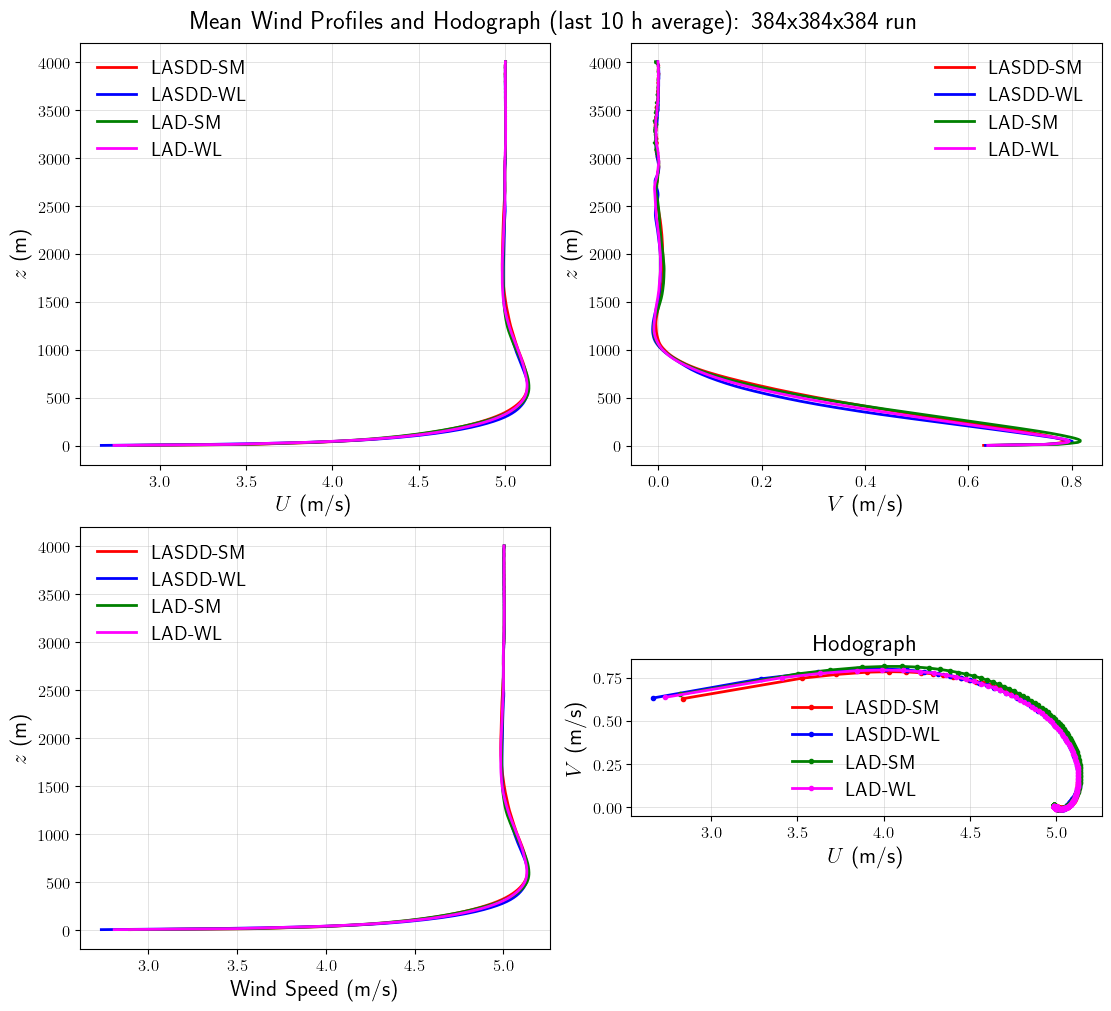

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
axs = axs.ravel()

run_styles = {
    'LASDD-SM': {'color': 'red',     'linestyle': '-'},
    'LASDD-WL': {'color': 'blue',    'linestyle': '-'},
    'LAD-SM':   {'color': 'green',   'linestyle': '-'},
    'LAD-WL':   {'color': 'magenta', 'linestyle': '-'},
}

def plot_run_profile(ax, x, z, xlabel, run_label):
    style = run_styles[run_label]
    ax.plot(x, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=run_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$z$ (m)")

plot_run_profile(axs[0], U_avg_1, z_1, r"$U$ (m/s)", 'LASDD-SM')
plot_run_profile(axs[0], U_avg_2, z_1, r"$U$ (m/s)", 'LASDD-WL')
plot_run_profile(axs[0], U_avg_3, z_1, r"$U$ (m/s)", 'LAD-SM')
plot_run_profile(axs[0], U_avg_4, z_1, r"$U$ (m/s)", 'LAD-WL')

plot_run_profile(axs[1], V_avg_1, z_1, r"$V$ (m/s)", 'LASDD-SM')
plot_run_profile(axs[1], V_avg_2, z_1, r"$V$ (m/s)", 'LASDD-WL')
plot_run_profile(axs[1], V_avg_3, z_1, r"$V$ (m/s)", 'LAD-SM')
plot_run_profile(axs[1], V_avg_4, z_1, r"$V$ (m/s)", 'LAD-WL')

plot_run_profile(axs[2], M_avg_1, z_1, r"Wind Speed (m/s)", 'LASDD-SM')
plot_run_profile(axs[2], M_avg_2, z_1, r"Wind Speed (m/s)", 'LASDD-WL')
plot_run_profile(axs[2], M_avg_3, z_1, r"Wind Speed (m/s)", 'LAD-SM')
plot_run_profile(axs[2], M_avg_4, z_1, r"Wind Speed (m/s)", 'LAD-WL')

axs[3].plot(U_avg_1, V_avg_1, color='red',     linestyle='-', marker='o', linewidth=2, markersize=3, label='LASDD-SM')
axs[3].plot(U_avg_2, V_avg_2, color='blue',    linestyle='-', marker='o', linewidth=2, markersize=3, label='LASDD-WL')
axs[3].plot(U_avg_3, V_avg_3, color='green',   linestyle='-', marker='o', linewidth=2, markersize=3, label='LAD-SM')
axs[3].plot(U_avg_4, V_avg_4, color='magenta', linestyle='-', marker='o', linewidth=2, markersize=3, label='LAD-WL')
axs[3].set_xlabel(r"$U$ (m/s)")
axs[3].set_ylabel(r"$V$ (m/s)")
axs[3].set_title('Hodograph')
axs[3].set_aspect('equal')

for ax in axs:
    ax.grid()
    ax.legend(frameon=False)

_res_label = {1: '64x64x64', 2: '128x128x128', 3: '256x256x256', 4: '384x384x384'}
fig.suptitle(f"Mean Wind Profiles and Hodograph (last 10 h average): {_res_label[optRes]} run", fontsize=18)
plt.show()

## Resolved Velocity Variances

The resolved variance profiles indicate how the resolved turbulent kinetic energy is distributed among the three velocity components.


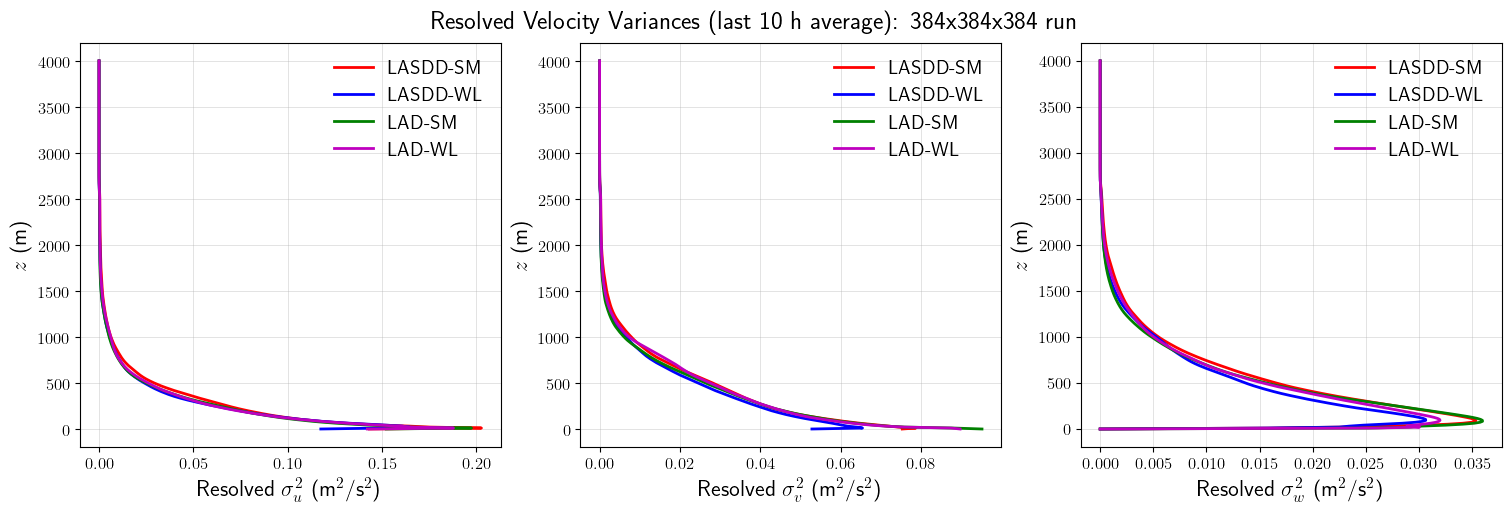

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(u2_avg_1, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[0], label='LASDD-SM')
plot_profile(u2_avg_2, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[0], label='LASDD-WL')
plot_profile(u2_avg_3, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-g', ax=axs[0], label='LAD-SM')
plot_profile(u2_avg_4, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-m', ax=axs[0], label='LAD-WL')

plot_profile(v2_avg_1, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[1], label='LASDD-SM')
plot_profile(v2_avg_2, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[1], label='LASDD-WL')
plot_profile(v2_avg_3, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-g', ax=axs[1], label='LAD-SM')
plot_profile(v2_avg_4, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-m', ax=axs[1], label='LAD-WL')

plot_profile(w2_avg_1, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[2], label='LASDD-SM')
plot_profile(w2_avg_2, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[2], label='LASDD-WL')
plot_profile(w2_avg_3, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-g', ax=axs[2], label='LAD-SM')
plot_profile(w2_avg_4, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-m', ax=axs[2], label='LAD-WL')

axs[0].grid(); axs[0].legend(frameon=False)
axs[1].grid(); axs[1].legend(frameon=False)
axs[2].grid(); axs[2].legend(frameon=False)

fig.suptitle(f"Resolved Velocity Variances (last 10 h average): {_res_label[optRes]} run", fontsize=18)
plt.show()

## Total Momentum Fluxes

The total vertical momentum flux combines resolved and SGS contributions. All four SGS models are compared at the selected resolution.

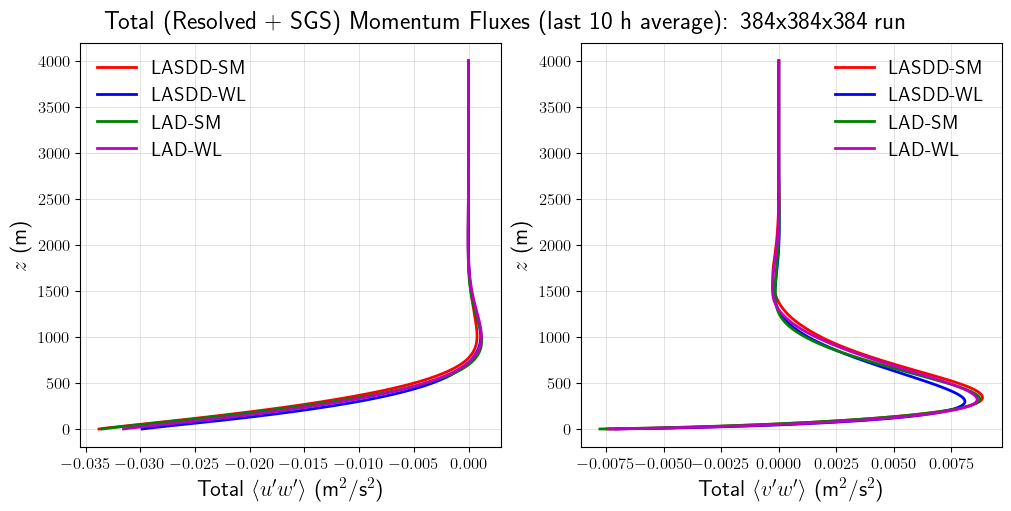

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

plot_profile(uw_tot_1, z_w_1, xlabel=r"Total $\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='-r', label='LASDD-SM', ax=axs[0])
plot_profile(uw_tot_2, z_w_1, xlabel=r"Total $\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='-b', label='LASDD-WL', ax=axs[0])
plot_profile(uw_tot_3, z_w_1, xlabel=r"Total $\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='-g', label='LAD-SM',   ax=axs[0])
plot_profile(uw_tot_4, z_w_1, xlabel=r"Total $\langle u'w' \rangle$ (m$^2$/s$^2$)", linestyle='-m', label='LAD-WL',   ax=axs[0])
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(vw_tot_1, z_w_1, xlabel=r"Total $\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='-r', label='LASDD-SM', ax=axs[1])
plot_profile(vw_tot_2, z_w_1, xlabel=r"Total $\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='-b', label='LASDD-WL', ax=axs[1])
plot_profile(vw_tot_3, z_w_1, xlabel=r"Total $\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='-g', label='LAD-SM',   ax=axs[1])
plot_profile(vw_tot_4, z_w_1, xlabel=r"Total $\langle v'w' \rangle$ (m$^2$/s$^2$)", linestyle='-m', label='LAD-WL',   ax=axs[1])
axs[1].grid()
axs[1].legend(frameon=False)

fig.suptitle(f"Total (Resolved + SGS) Momentum Fluxes (last 10 h average): {_res_label[optRes]} run", fontsize=18)
plt.show()